In [1]:
import joblib
import pandas as pd
import numpy as np

### Load Models

In [2]:
base_model = joblib.load("../../code/models/linear_ar/lin_base_market_only.pkl")
mm_model   = joblib.load("../../code/models/linear_ar/lin_mm_multimodal.pkl")

### Extract coefficients

In [3]:
coef_base = pd.Series(base_model.coef_, index=base_model.feature_names_in_, name="coef_base")
coef_mm   = pd.Series(mm_model.coef_,   index=mm_model.feature_names_in_,   name="coef_mm")


### Combine for comparison

In [4]:
# 1) Get the full set of features across both models
all_features = sorted(set(coef_base.index) | set(coef_mm.index))

# 2) Reindex both coefficient series → fill missing with zero
coef_base_full = coef_base.reindex(all_features).fillna(0)
coef_mm_full   = coef_mm.reindex(all_features).fillna(0)

# 3) Build the comparison table
coef_df = pd.DataFrame({
    "coef_base": coef_base_full,
    "coef_mm": coef_mm_full
})

coef_df["delta"] = coef_df["coef_mm"] - coef_df["coef_base"]

coef_df



,coef_base,coef_mm,delta
px_ma200,-0.002138,-0.002103,3.433801e-05
px_ma21,0.002545,0.002542,-2.875816e-06
px_ma63,-0.000528,-0.000547,-1.878377e-05
ret_ema21,0.000695,0.000687,-8.222802e-06
ret_ema63,-0.001594,-0.001585,8.594432e-06
ret_lag1,0.000441,0.000442,1.060114e-06
ret_lag2,0.000136,0.000138,1.352920e-06
ret_lag3,0.000482,0.000486,3.466015e-06
ret_lag4,0.000595,0.000596,1.203033e-06
ret_lag5,-0.000697,-0.000698,-5.551216e-07


In [5]:
coef_df.to_csv("../results/linear_ar/coef_comparison.csv", index=True)


### Plot (Top 15 coefficient changes)

C:\Users\mkcak\AppData\Local\Temp\ipykernel_8936\873967810.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


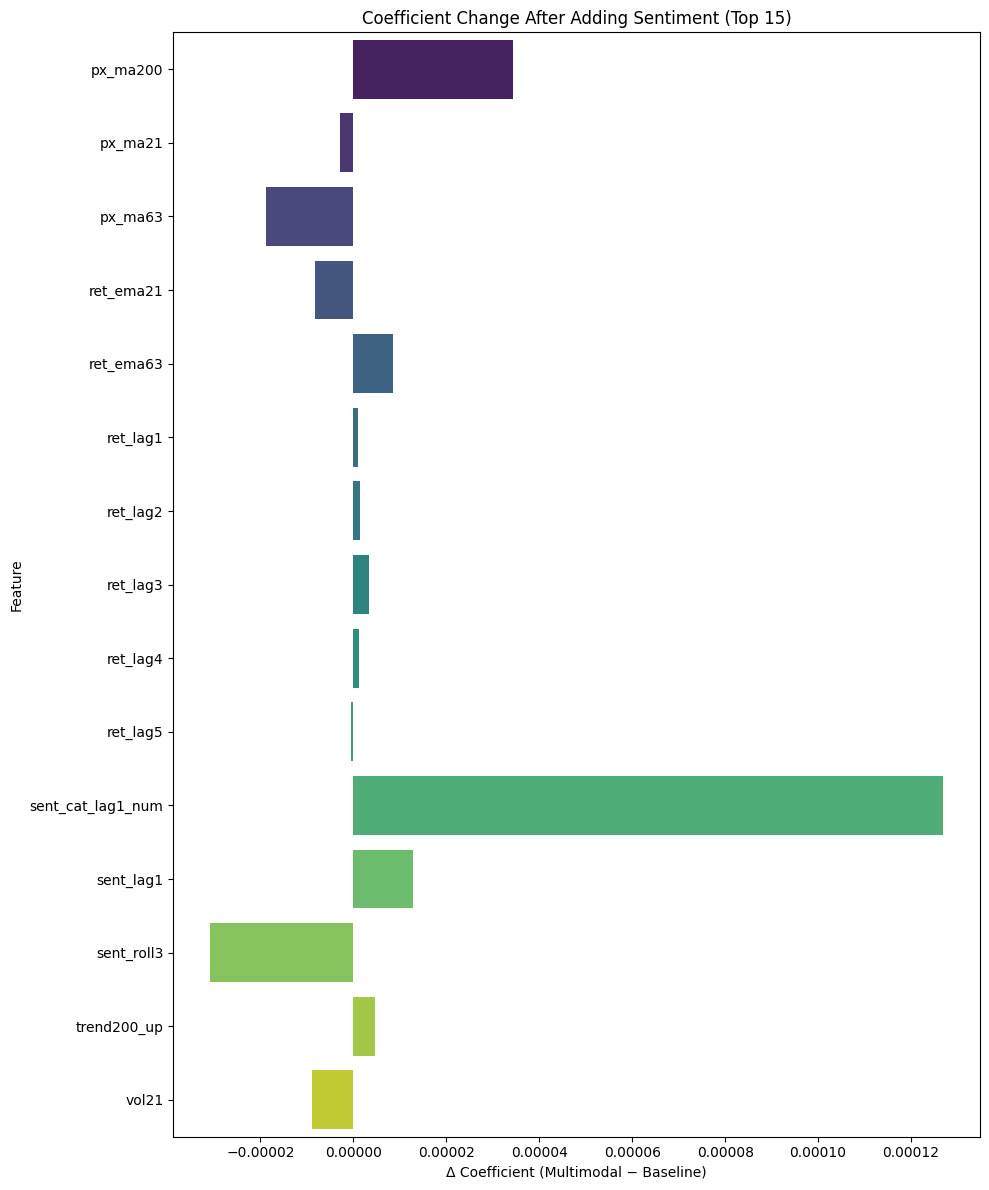

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,12))
sns.barplot(
    data=coef_df.head(15).reset_index(),
    x="delta",
    y="index",
    palette="viridis"
)
plt.title("Coefficient Change After Adding Sentiment (Top 15)")
plt.xlabel("Δ Coefficient (Multimodal − Baseline)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [7]:
# Save the figure to the specified directory
plt.figure(figsize=(10,12))
ax = sns.barplot(
    data=coef_df.head(15).reset_index(),
    x="delta",
    y="index",
    palette="viridis"
)
plt.title("Coefficient Change After Adding Sentiment (Top 15)")
plt.xlabel("Δ Coefficient (Multimodal − Baseline)")
plt.ylabel("Feature")
plt.tight_layout()
save_dir = "../results/linear_ar"
plt.savefig(f"{save_dir}/coef_change_top15.png", bbox_inches="tight")
plt.close()


C:\Users\mkcak\AppData\Local\Temp\ipykernel_8936\4231786583.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


### Focused Sentiment Interpretation

In [8]:
coef_base_full = coef_base.reindex(all_features).fillna(0.0)
coef_mm_full   = coef_mm.reindex(all_features).fillna(0.0)  # should already be non-NaN

# 4) Build comparison table and compute delta
coef_df = pd.DataFrame({
    "coef_base": coef_base_full,
    "coef_mm": coef_mm_full,
})
coef_df["delta"] = coef_df["coef_mm"] - coef_df["coef_base"]

# 5) Check sentiment rows
sent_features = ["sent_lag1", "sent_cat_lag1_num", "sent_roll3"]
coef_df.loc[sent_features]

,coef_base,coef_mm,delta
sent_lag1,0.0,0.000013,0.000013
sent_cat_lag1_num,0.0,0.000127,0.000127
sent_roll3,0.0,-0.000031,-0.000031


In [9]:
# Save the sentiment coefficients comparison to CSV
sentiment_csv_path = "../results/linear_ar/sentiment_comparison.csv"
coef_df.loc[sent_features].to_csv(sentiment_csv_path, float_format="%.6f")
